<div style="text-align:center; font-family:Georgia, serif; background-color:#f5f5f5; padding:10px;">

  <h1 style="margin:0; padding:8px 0;">
     Twitter Financial News Analysis
  </h1>
</div>

Creating a Twitter Financial News Analysis project involves building a pipeline that processes, analyzes, and models financial sentiments. 

Problem Definition
- Objective: Analyze Twitter financial news and classify sentiments (e.g.,
Positive, Neutral, Negative) or financial impacts (e.g., Bullish,
Bearish).
- Data:

○ text: Tweets or news text related to financial markets.

○ label: The sentiment or impact associated with each text (categorical
values)

### 1. Preprocessing

In [31]:
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("wordnet")
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

|Resourse| What it is |Purpose |
|------|-----|------|
|`stopwords`|A list of common 'filler' words |Used to filter out words that carry little unique meaning so you can focus on the important keywords(e.g., ""the"", ""is"", ""at"").|
|`wordnet`|A large lexical database/thesaurus for English.|Powers the `WordNetLemmatizer` to help link words like ""feet"" to ""foot"" or ""ran"" to ""run."|
|`punkt`|A pre-trained model for tokenization.|It knows where sentences and words end, even with tricky punctuation (like knowing ""U.S.A."" is one word, not three sentences)."|

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from nltk import WordNetLemmatizer
from nltk import word_tokenize
import nltk
from wordcloud import WordCloud
import re
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Dense, Embedding,LSTM, Bidirectional, GRU, GlobalMaxPooling1D, Dropout,SimpleRNN, Conv1D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy, categorical_crossentropy
from sklearn.feature_extraction.text import CountVectorizer

In [33]:
# get stopwords
stops = set(stopwords.words("english"))

In [34]:
df_train = pd.read_csv("train_data.csv")
df_test = pd.read_csv("valid_data.csv")

In [35]:
df_train.head()

,text,label
0,Here are Thursday's biggest analyst calls: App...,0
1,Buy Las Vegas Sands as travel to Singapore bui...,0
2,"Piper Sandler downgrades DocuSign to sell, cit...",0
3,"Analysts react to Tesla's latest earnings, bre...",0
4,Netflix and its peers are set for a ‘return to...,0


In [36]:
df_test.head()

,text,label
0,Analyst call of the day for @CNBCPro subscribe...,0
1,"Loop upgrades CSX to buy, says it's a good pla...",0
2,BofA believes we're already in a recession — a...,0
3,JPMorgan sees these derivative plays as best w...,0
4,Morgan Stanley's Huberty sees Apple earnings m...,0


In [37]:
train_labels = df_train["label"]
train_corpus = df_train["text"]

test_labels = df_test["label"]
test_corpus = df_test["text"]

In [38]:
train_labels

0        0
1        0
2        0
3        0
4        0
        ..
16985    3
16986    3
16987    3
16988    3
16989    3
Name: label, Length: 16990, dtype: int64

In [39]:
train_corpus

0        Here are Thursday's biggest analyst calls: App...
1        Buy Las Vegas Sands as travel to Singapore bui...
2        Piper Sandler downgrades DocuSign to sell, cit...
3        Analysts react to Tesla's latest earnings, bre...
4        Netflix and its peers are set for a ‘return to...
                               ...                        
16985    KfW credit line for Uniper could be raised to ...
16986    KfW credit line for Uniper could be raised to ...
16987    Russian  https://t.co/R0iPhyo5p7 sells 1 bln r...
16988    Global ESG bond issuance posts H1 dip as supra...
16989    Brazil's Petrobras says it signed a $1.25 bill...
Name: text, Length: 16990, dtype: object

In [40]:
# get correct mapping of ordinal encoded target variables
label_mapping = {"LABEL_0": "Analyst Update",
"LABEL_1": "Fed | Central Banks",
"LABEL_2": "Company | Product News",
"LABEL_3": "Treasuries | Corporate Debt",
"LABEL_4": "Dividend",
"LABEL_5": "Earnings",
"LABEL_6": "Energy | Oil",
"LABEL_7": "Financials",
"LABEL_8": "Currencies",
"LABEL_9": "General News | Opinion",
"LABEL_10": "Gold | Metals | Materials",
"LABEL_11": "IPO",
"LABEL_12": "Legal | Regulation",
"LABEL_13": "M&A | Investments",
"LABEL_14": "Macro",
"LABEL_15": "Markets",
"LABEL_16": "Politics",
"LABEL_17": "Personnel Change",
"LABEL_18": "Stock Commentary",
"LABEL_19": "Stock Movement"
}

In [41]:
label_mapping = {k:v for k,v in zip(range(20),label_mapping.values())}

In [42]:
# get understanding of the text data
# number of the random articles
S = 5
inds = np.random.choice(train_corpus.index, 5)
for i in inds:
    print(train_corpus[i])

Thunderbird Distribution acquires global media and consumer products rights to new preschool series Mittens &amp; Pants  https://t.co/x2Beq8NfuY  https://t.co/fVlBQBfYeN
Quebec’s pension manager broke its silence about its investment in Celsius Network, saying it will “take time” to resolve claims around the bankrupt cryptocurrency lender  https://t.co/SKRNAOvjGw
@ThePharaoh20 it has huge potential imo but unfortunately it's not recognized.
It's time for Trump to 'sail into the sunset,' says Musk - Reuters   https://t.co/Ea8rL5LDOT
$VKTX: Viking Therapeutics announces FDA has lifted clinical hold on Phase 1b trial of VK0214 in patients with X-ALD  https://t.co/y9INdkDbNc


In [43]:
# there is a need to remove all hyperlinks, since they do not contain any contextual text data
def remove_hyperlinks_and_punctuation(text):
    pattern = r'\bhttps?:\/\/\S+|[^\w\s]'
    new_text = re.sub(pattern, "", text)
    return new_text

In [44]:
train_corpus_cleaned = train_corpus.apply(lambda x: remove_hyperlinks_and_punctuation(x))
test_corpus_cleaned = test_corpus.apply(lambda x: remove_hyperlinks_and_punctuation(x))

In [45]:
for i in inds:
    print(train_corpus_cleaned[i])

Thunderbird Distribution acquires global media and consumer products rights to new preschool series Mittens amp Pants    
Quebecs pension manager broke its silence about its investment in Celsius Network saying it will take time to resolve claims around the bankrupt cryptocurrency lender  
ThePharaoh20 it has huge potential imo but unfortunately its not recognized
Its time for Trump to sail into the sunset says Musk  Reuters   
VKTX Viking Therapeutics announces FDA has lifted clinical hold on Phase 1b trial of VK0214 in patients with XALD  


## 2. Tokenize corpus

In [46]:
# use count vectorizer to feed in ANN without paying attention to the sequence
# Could make sense, because classifcation of the source of the news may not be dependent on the sequence of the words, but rather on some certain important words which are unique for the source

class LemmaTokenizer(object):
    def __init__(self):
        self.wnl = WordNetLemmatizer()
    def __call__(self, articles):
        return [self.wnl.lemmatize(t) for t in
word_tokenize(articles)]
        
MAX_VOCAB_SIZE_ANN = 18000

vectorizer = CountVectorizer(tokenizer=LemmaTokenizer(),
stop_words=list(stops), max_features=MAX_VOCAB_SIZE_ANN)
vectorizer.fit(train_corpus_cleaned)
train_data_ann = vectorizer.transform(train_corpus_cleaned)
test_data_ann = vectorizer.transform(test_corpus_cleaned)

C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ["'d", "'ll", "'m", "'re", "'s", "'ve", 'could', 'doe', 'ha', 'might', 'must', "n't", 'need', 'sha', 'wa', 'wo', 'would'] not in stop_words.
  warnings.warn(


In [47]:
# create batch generator to feed sparse matrix into keras fit method

def batch_generator(X, y, batch_size):
    number_of_batches = X.shape[0]/batch_size
    counter=0
    
    shuffle_index = np.arange(np.shape(y)[0])
    np.random.shuffle(shuffle_index)
    
    X = X[shuffle_index, :]
    y = y[shuffle_index]
    
    while 1:
        # each batch contains all the shuffled indices
        
        index_batch = shuffle_index[batch_size*counter :
        batch_size*(counter+1)]
        X_batch = X[index_batch,:].todense()
        y_batch = y[index_batch]
        counter += 1
        
        yield(np.array(X_batch),y_batch)
        if (counter < number_of_batches):
            np.random.shuffle(shuffle_index)
            counter=0

In [48]:
# Apply lemmatization to corpus- remove maybe later in case of poor performance
# used for sequence models

wnl = WordNetLemmatizer()

def lemmatize_sentence(sentence):
    tokens = [wnl.lemmatize(t) for t in word_tokenize(sentence)]
    return (" ").join(tokens)
    
train_corpus_cleaned = train_corpus_cleaned.apply(lambda x:lemmatize_sentence(x))
test_corpus_cleaned = test_corpus_cleaned.apply(lambda x:lemmatize_sentence(x))

In [49]:
for i in inds:
    print(train_corpus_cleaned[i])

Thunderbird Distribution acquires global medium and consumer product right to new preschool series Mittens amp Pants
Quebecs pension manager broke it silence about it investment in Celsius Network saying it will take time to resolve claim around the bankrupt cryptocurrency lender
ThePharaoh20 it ha huge potential imo but unfortunately it not recognized
Its time for Trump to sail into the sunset say Musk Reuters
VKTX Viking Therapeutics announces FDA ha lifted clinical hold on Phase 1b trial of VK0214 in patient with XALD


In [50]:
# transform the corpus to get training and test data

MAX_VOCAB_SIZE = 30000

tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="OOV",lower=True)
tokenizer.fit_on_texts(train_corpus_cleaned)
train_data = tokenizer.texts_to_sequences(train_corpus_cleaned)
test_data = tokenizer.texts_to_sequences(test_corpus_cleaned)

In [51]:
# get max len of sentences for padding
maxlen1 = max(len(sent) for sent in train_data)
maxlen2 = max(len(sent) for sent in test_data)
T = max(maxlen1, maxlen2)
print(T)

64


In [52]:
word2idx = tokenizer.word_index
V = len(word2idx)
print("The corpus contains %s words!" % V)

The corpus contains 25561 words!


In [53]:
# pad sequences
train_data_padded = pad_sequences(train_data, maxlen=T)
test_data_padded = pad_sequences(test_data, maxlen=T)

In [90]:
print("Train tensor shape:", train_data_padded.shape)
print("Test tensor shape:", test_data_padded.shape)

Train tensor shape: (16990, 64)
Test tensor shape: (4117, 64)


In [55]:
# get class number
K = len(set(train_labels))
print(f"We have %s unique labels!" % K)

We have 20 unique labels!


### 3. Data overview and visualization

In [57]:
# show word overview with wordcloud
# not using all words, but rather subsamples
random_subsample_word_wordcloud_size = round(len(train_corpus_cleaned) * 0.33)
wordcloud_ids = np.random.choice(len(train_corpus_cleaned),
random_subsample_word_wordcloud_size)
concat_text = ""
for i in wordcloud_ids:
    concat_text += " " + train_corpus_cleaned[i]
    
wordcloud = WordCloud(background_color="white", width=800, height=400, stopwords=stops).generate(concat_text)

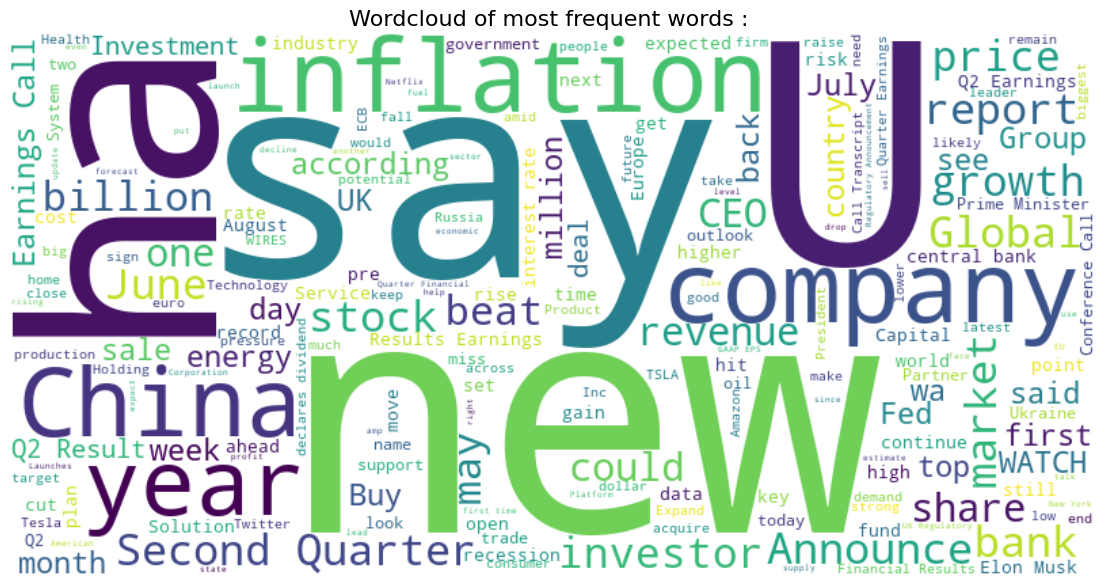

In [60]:
fig, ax = plt.subplots(figsize=(14,10))
ax.imshow(wordcloud, interpolation="bilinear")
ax.axis("off")
plt.title("Wordcloud of most frequent words : ", fontsize=16)
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12596\1223822336.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=train_labels, ax=ax, palette="hls")


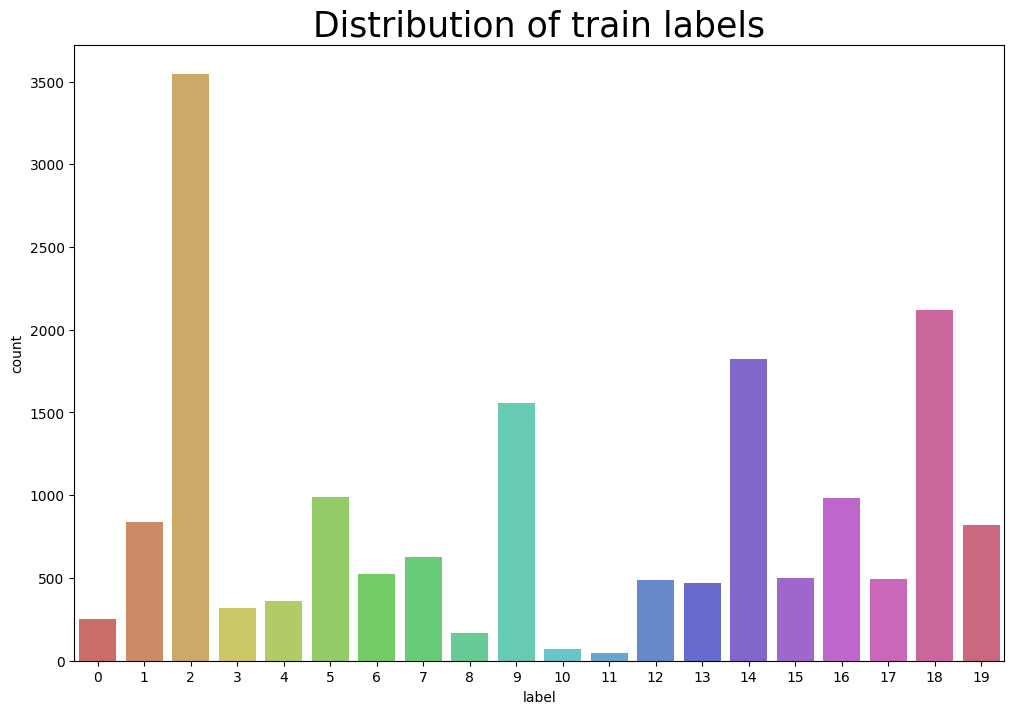

In [64]:
# distribution of train targets

fig, ax = plt.subplots(figsize=(12,8))

sns.countplot(x=train_labels, ax=ax, palette="hls")
plt.title("Distribution of train labels", fontsize=25)

plt.show()

##### As we observe it is highly imbalanced data!!

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12596\886383970.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=test_labels, ax=ax,palette="hls")


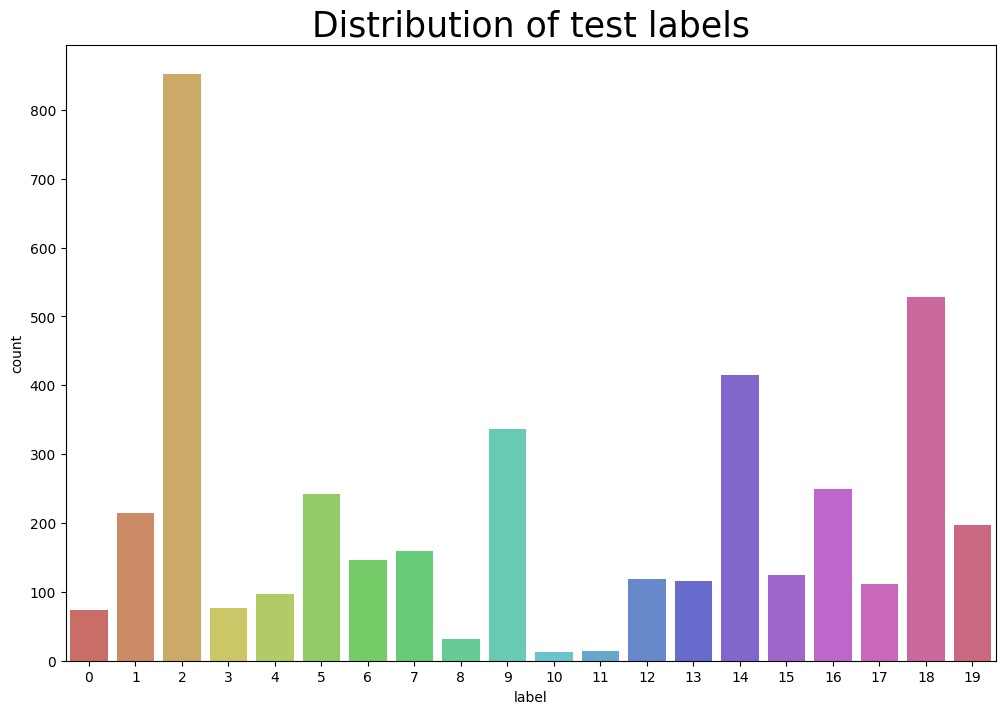

Highly imbalanced data!!


In [66]:
# distribution of train targets
fig, ax = plt.subplots(figsize=(12,8))
sns.countplot(x=test_labels, ax=ax,palette="hls")
plt.title("Distribution of test labels", fontsize=25)
plt.show()
print("Highly imbalanced data!!")

##### Similarly, this is also highly imbalanced data!!

In [68]:
# highly imblanced data, so inverse class weights are computed for the loss function

class_weights = train_labels.value_counts(normalize=True).sort_index()
inverse_class_weights = class_weights.apply(lambda x: 1 / x)
inverse_class_weights

label
0      66.627451
1      20.298686
2       4.792666
3      52.928349
4      47.325905
5      17.213779
6      32.423664
7      27.227564
8     102.349398
9      10.912010
10    246.231884
11    386.136364
12     34.887064
13     36.072187
14      9.324918
15     33.912176
16     17.248731
17     34.323232
18      8.021719
19     20.643985
Name: proportion, dtype: float64

### 4. Build the model

In [70]:
# Embedding dimension
D = 64
hidden_states1 = 12

def make_model_rnn():
    with tf.device("/GPU:0"):
        # 1. Input Layer: Takes sequences of length T
        i = Input(shape=(T,))
        
        # 2. Embedding: Turns word IDs into dense vectors of size D
        x = Embedding(V + 1, D)(i)
        
        # 3. RNN: Processes sequence; return_sequences=True keeps the time dimension
        x = SimpleRNN(hidden_states1, return_sequences=True)(x)
        
        # 4. Pooling: Picks the most important signal across the whole sentence
        x = GlobalMaxPooling1D()(x)
        
        # 5. Dense/Dropout: Classification head with regularization
        x = Dense(64, activation="relu")(x)
        x = Dropout(0.5)(x)
        
        # 6. Output: K classes with Softmax probabilities
        x = Dense(K, activation="softmax")(x)
        
        model = Model(i, x)
        model.compile(
            loss=SparseCategoricalCrossentropy(), 
            optimizer=Adam(learning_rate=0.001), 
            metrics=["accuracy"]
        )
        return model

In [72]:
def make_model_cnn():
    with tf.device("/GPU:0"):
        # 1. Input: Sequences of length T
        i = Input(shape=(T,))
        
        # 2. Embedding: Word vectors of dimension D
        x = Embedding(V + 1, D)(i)
        
        # 3. Conv1D: 32 filters, each looking at 3 words at a time (kernel size 3)
        x = Conv1D(32, 3, activation='relu')(x)
        
        # 4. Pooling: Reduces the sequence to the most prominent features
        x = GlobalMaxPooling1D()(x)
        
        # 5. Classifier Head
        x = Dense(64, activation="relu")(x)
        x = Dropout(0.3)(x)
        
        # 6. Output: K classes
        x = Dense(K, activation="softmax")(x)
        
        model = Model(i, x)
        
        # Using SGD with momentum as specified
        model.compile(
            loss=SparseCategoricalCrossentropy(),
            optimizer=SGD(learning_rate=0.0001, momentum=0.9),
            metrics=["accuracy"]
        )
        return model

In [78]:
def make_model_ann():
    with tf.device("/GPU:0"):
        # 1. Input: Expects a flat vector of size MAX_VOCAB_SIZE_ANN (e.g., 18000)
        i = Input(shape=(MAX_VOCAB_SIZE_ANN,))
        
        # 2. Dense Layers: Learning complex patterns through weight adjustment
        x = Dense(1028, activation="relu")(i)
        x = Dropout(0.2)(x)
        
        x = Dense(512, activation="relu")(x)
        x = Dropout(0.2)(x)
        
        x = Dense(256, activation="relu")(x)
        
        # 3. Output: K classes
        x = Dense(K, activation="softmax")(x)
        
        model = Model(i, x)
        
        model.compile(
            loss=SparseCategoricalCrossentropy(),
            optimizer=SGD(learning_rate=0.0001, momentum=0.9),
            metrics=["accuracy"]
        )
        return model

### 5. Fit the model

In [75]:
model = make_model_cnn()
print(model.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding (Embedding)                │ (None, 64, 64)              │       1,635,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d (Conv1D)                      │ (None, 62, 32)              │           6,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling1d                 │ (None, 32)                  │               0 │
│ (GlobalMaxPooling1D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 20)                  │           1,300 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,645,556 (6.28 MB)

 Trainable params: 1,645,556 (6.28 MB)

 Non-trainable params: 0 (0.00 B)

None


In [76]:
r1 = model.fit(train_data_padded, train_labels, epochs=100,
               batch_size=32, validation_data=(test_data_padded, test_labels),
               class_weight=dict(inverse_class_weights)
              )

Epoch 1/100
531/531 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.0496 - loss: 59.8738 - val_accuracy: 0.0782 - val_loss: 2.9865
Epoch 2/100
531/531 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.0529 - loss: 59.6535 - val_accuracy: 0.0935 - val_loss: 2.9716
Epoch 3/100
531/531 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.0861 - loss: 59.2348 - val_accuracy: 0.1195 - val_loss: 2.9357
Epoch 4/100
531/531 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1029 - loss: 58.4290 - val_accuracy: 0.1161 - val_loss: 2.9039
Epoch 5/100
531/531 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1060 - loss: 57.4982 - val_accuracy: 0.1219 - val_loss: 2.8712
Epoch 6/100
531/531 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1180 - loss: 56.2281 - val_accuracy: 0.1494 - val_loss: 2.8004
Epoch 7/100
531/531 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1395 - loss: 53.1510 - val_accuracy: 0.1598 - val_loss: 2.6876
Epoch 8/100
531/531 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1618 - loss: 49.1973 - 

In [79]:
# train also a simple ANN
model2 = make_model_ann()
print(model2.summary())

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 18000)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1028)                │      18,505,028 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 1028)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 512)                 │         526,848 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 20)                  │           5,140 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,168,344 (73.12 MB)

 Trainable params: 19,168,344 (73.12 MB)

 Non-trainable params: 0 (0.00 B)

None


In [80]:
r2 = model2.fit(
    train_data_ann.toarray(), 
    train_labels,epochs=100, batch_size=32,
    validation_data=(test_data_ann.toarray(),test_labels),
    class_weight=dict(inverse_class_weights), shuffle=True    
)

Epoch 1/100
531/531 ━━━━━━━━━━━━━━━━━━━━ 47s 87ms/step - accuracy: 0.1208 - loss: 59.1802 - val_accuracy: 0.2524 - val_loss: 2.8914
Epoch 2/100
531/531 ━━━━━━━━━━━━━━━━━━━━ 40s 75ms/step - accuracy: 0.3018 - loss: 51.8318 - val_accuracy: 0.3665 - val_loss: 2.3933
Epoch 3/100
531/531 ━━━━━━━━━━━━━━━━━━━━ 41s 78ms/step - accuracy: 0.4577 - loss: 31.8228 - val_accuracy: 0.5438 - val_loss: 1.5900
Epoch 4/100
531/531 ━━━━━━━━━━━━━━━━━━━━ 42s 79ms/step - accuracy: 0.6116 - loss: 18.9226 - val_accuracy: 0.6757 - val_loss: 1.1961
Epoch 5/100
531/531 ━━━━━━━━━━━━━━━━━━━━ 41s 77ms/step - accuracy: 0.6995 - loss: 13.3383 - val_accuracy: 0.7097 - val_loss: 1.0286
Epoch 6/100
531/531 ━━━━━━━━━━━━━━━━━━━━ 44s 82ms/step - accuracy: 0.7523 - loss: 10.1516 - val_accuracy: 0.7163 - val_loss: 0.9493
Epoch 7/100
531/531 ━━━━━━━━━━━━━━━━━━━━ 42s 79ms/step - accuracy: 0.7961 - loss: 7.9321 - val_accuracy: 0.7641 - val_loss: 0.7854
Epoch 8/100
531/531 ━━━━━━━━━━━━━━━━━━━━ 42s 79ms/step - accuracy: 0.8281 - l

### 6. Evaluation

Note: A sequence model like **RNN** or **LSTM** was not considered because it was overfitting strongly. The CNNperformed much better for the sequence and Embedding data
##### 6.1 Plain Feedforward Network Evaluation

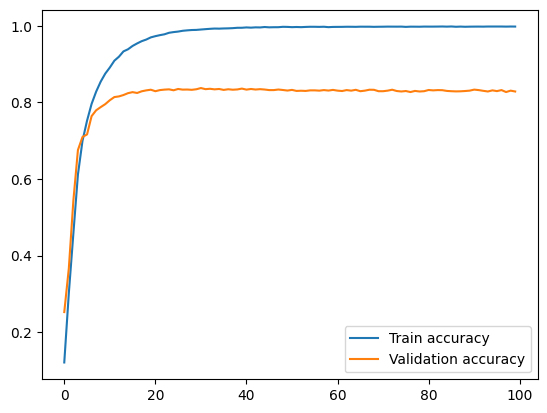

In [82]:
plt.plot(r2.history["accuracy"], label="Train accuracy")
plt.plot(r2.history["val_accuracy"], label="Validation accuracy")
plt.legend()
plt.show()

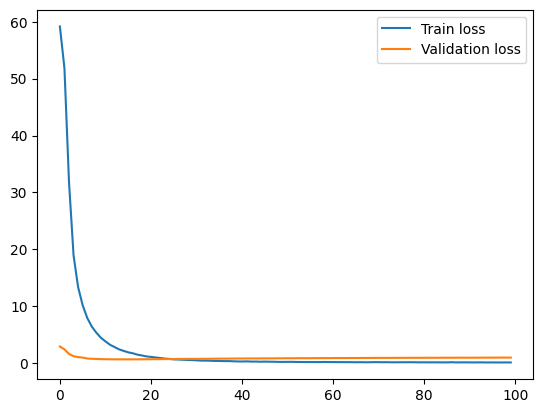

In [83]:
plt.plot(r2.history["loss"], label="Train loss")
plt.plot(r2.history["val_loss"], label="Validation loss")
plt.legend()
plt.show()

In [84]:
from sklearn.metrics import f1_score, classification_report
preds = np.argmax(model2.predict(test_data_ann), axis=1)

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


In [85]:
print("Classification report for test data")
print(classification_report(preds,test_labels))

Classification report for test data
              precision    recall  f1-score   support

           0       0.67      0.86      0.75        57
           1       0.86      0.88      0.87       209
           2       0.85      0.83      0.84       870
           3       0.75      0.92      0.83        63
           4       0.99      0.96      0.97       100
           5       0.94      0.88      0.91       259
           6       0.79      0.82      0.81       141
           7       0.83      0.86      0.85       154
           8       0.84      0.77      0.81        35
           9       0.78      0.70      0.74       375
          10       0.62      0.38      0.47        21
          11       0.93      0.81      0.87        16
          12       0.79      0.87      0.83       108
          13       0.70      0.82      0.75        99
          14       0.83      0.81      0.82       422
          15       0.77      0.76      0.76       127
          16       0.87      0.91      0.89  

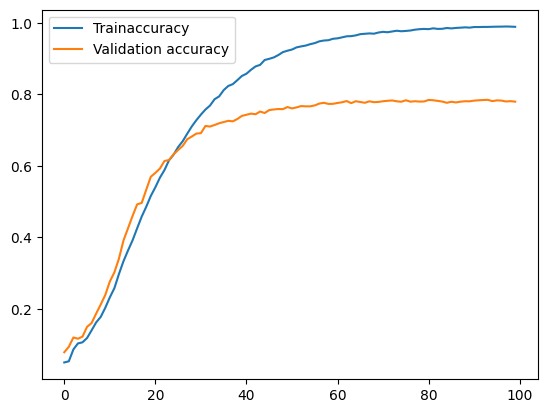

In [87]:
#PlainFeedforwardNetworkEvaluation

plt.plot(r1.history["accuracy"],label="Trainaccuracy")
plt.plot(r1.history["val_accuracy"],label="Validation accuracy")
plt.legend()
plt.show()

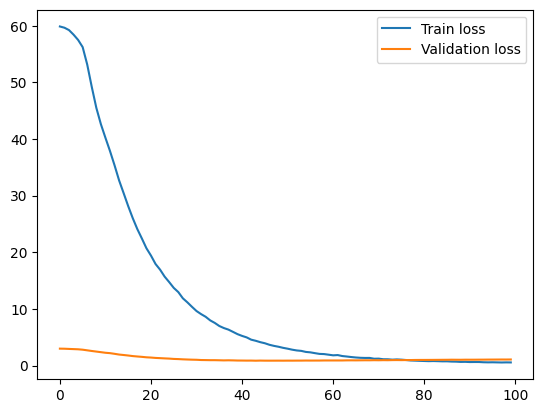

In [88]:
plt.plot(r1.history["loss"], label="Train loss")
plt.plot(r1.history["val_loss"], label="Validation loss")
plt.legend()
plt.show()

In [89]:
preds = np.argmax(model .predict(test_data_padded), axis=1)
print("Classification report for test data")
print(classification_report(preds,test_labels))

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step   
Classification report for test data
              precision    recall  f1-score   support

           0       0.47      0.72      0.57        47
           1       0.81      0.84      0.82       206
           2       0.80      0.74      0.77       920
           3       0.73      0.88      0.79        64
           4       0.98      0.96      0.97        99
           5       0.93      0.93      0.93       243
           6       0.77      0.81      0.79       138
           7       0.84      0.83      0.83       162
           8       0.88      0.82      0.85        34
           9       0.70      0.62      0.66       378
          10       0.85      0.52      0.65        21
          11       1.00      0.88      0.93        16
          12       0.67      0.82      0.74        97
          13       0.62      0.73      0.67        99
          14       0.76      0.76      0.76       415
          15       0.71      0.77      0.74       116
 

### Conclusion
A feed‑forward neural network using a bag‑of‑words representation yielded the highest accuracy (83\%) on the Twitter financial news dataset. Sequence‑based models (RNN, CNN) did not outperform the simpler ANN, suggesting that for this task, word presence is more informative than word order. Further improvements may be obtained by employing more sophisticated architectures (e.g., Transformers) or advanced data augmentation techniques to handle class imbalance.